In [1]:
from google.colab import files
uploaded = files.upload()

Saving heards_structured_cleaned_v11.csv to heards_structured_cleaned_v11.csv


In [2]:
# Core
import os, math, re, gc, warnings
import numpy as np
import pandas as pd
from datetime import datetime, timedelta, timezone

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, brier_score_loss
from scipy.special import logit, expit
from scipy.stats import spearmanr

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 200)


In [3]:
CFG = {
    # Time handling
    "timestamp_col_candidates": ["updatedDate", "start_date", "end_date"],
    "sgt_cutoff_hour": 17,                  # 17:00 SGT daily bucket close
    "sgt_tz": "Asia/Singapore",
    # Text
    "headline_col_candidates": ["headline", "headlines", "text", "Title", "title"],
    "mask_company_tokens": True,
    "mask_location_tokens": True,
    "max_per_party_per_day": 8,            # cap per 'party' per day (None to disable)
    # Modeling
    "rolling_vocab_lookback_days": 365,    # TF-IDF trained on this many days of history
    "retrain_cadence_days": 30,            # retrain every N days
    "min_df": 3,
    "ngram_range": (1,2),
    "C": 2.0,
    # Pooling across headlines within a day
    "pooling": "logit_mean",               # one of {"mean", "logit_mean", "top_m"}
    "top_m": 5,
    # Labeling / evaluation
    "price_csv_path": None,                # set to path when you have prices, e.g., "/content/mops380_prices.csv"
    "price_date_col": "date",
    "price_close_col": "close",
    "epsilon_mode": "sigma",               # {"abs", "sigma"} dead-zone; unlabeled if |ret| <= ε
    "epsilon_value": 0.20,                 # if abs -> e.g. 0.001; if sigma -> fraction of rolling std (e.g., 0.20 = 0.2σ)
    "epsilon_window": 60,                  # rolling window for σ
    # Decision layer (backtest)
    "abstain_band": 0.05,                  # abstain if p in [0.5±band]
    "vol_target_daily": 0.01,              # target daily vol (position scaling)
    "max_leverage": 1.0,
}


In [5]:
# 2) Load your uploaded CSV and basic normalization (FIXED TZ CONVERT)
# Replace with your uploaded filename if different
DATA_PATH = "heards_structured_cleaned_v11.csv"
df = pd.read_csv(DATA_PATH, low_memory=False)

# Identify timestamp + headline columns
ts_candidates = CFG["timestamp_col_candidates"]
text_candidates = CFG["headline_col_candidates"]

ts_col = next((c for c in ts_candidates if c in df.columns), None)
text_col = next((c for c in text_candidates if c in df.columns), None)
if ts_col is None or text_col is None:
    raise ValueError(
        f"Could not find timestamp ({ts_candidates}) and/or headline ({text_candidates}) columns. "
        f"Available columns: {list(df.columns)}"
    )

# Parse to timezone-aware SGT
# - utc=True: treat naive timestamps as UTC (safe default), convert any tz-aware to UTC
# - then convert UTC -> Asia/Singapore using .dt.tz_convert(...)
s_utc = pd.to_datetime(df[ts_col], errors="coerce", utc=True)
df["_dt_sgt"] = s_utc.dt.tz_convert("Asia/Singapore")

# Drop rows with invalid time or empty headline
df[text_col] = df[text_col].astype(str).str.strip()
df = df.dropna(subset=["_dt_sgt", text_col]).reset_index(drop=True)

# Define bucket end at 17:00 SGT
def bucket_day(dt_sgt, cutoff_hour=17):
    day = dt_sgt.date()
    # If time < 17:00 => same calendar day; >= 17:00 => next day
    return pd.Timestamp(day) if dt_sgt.hour < cutoff_hour else (pd.Timestamp(day) + pd.Timedelta(days=1))

df["_bucket_day"] = df["_dt_sgt"].apply(lambda d: bucket_day(d, CFG["sgt_cutoff_hour"]))


In [6]:
# 3) Dedupe + optional masking

# --- helpers ---
def norm_text(s: str) -> str:
    s = s.lower()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"[^\w\s\$\%\-/:\.]", "", s)  # keep finance-ish symbols
    return s.strip()

def mask_tokens(s: str, mask_company=True, mask_location=True, loc_candidates=None) -> str:
    t = s
    if mask_company:
        # Uppercase tokens (length ≥ 2) → <CPY>  (e.g., TRAFI, VITOL)
        t = re.sub(r"\b([A-Z][A-Z0-9&\.-]{1,})\b", "<CPY>", t)
    if mask_location and loc_candidates:
        for loc in loc_candidates:
            if isinstance(loc, str) and len(loc) >= 3:
                t = re.sub(rf"\b{re.escape(loc)}\b", "<LOC>", t, flags=re.IGNORECASE)
    return t

# --- normalize text for dedupe ---
before_rows = len(df)
df["_text_norm"] = df[text_col].map(norm_text)

# exact dedupe within the same *bucket day*
df = df.sort_values("_dt_sgt")
df = df.drop_duplicates(subset=["_bucket_day", "_text_norm"]).reset_index(drop=True)
after_dedup_rows = len(df)

# optional cap per 'party' per day (avoid single-source dominance)
capped_rows = None
if CFG.get("max_per_party_per_day") and "party" in df.columns:
    def _cap_group(g):
        return g.head(CFG["max_per_party_per_day"])
    df = (df
          .sort_values("_dt_sgt")
          .groupby(["_bucket_day", "party"], group_keys=False)
          .apply(_cap_group)
          .reset_index(drop=True))
    capped_rows = len(df)

# --- masking (company/location) ---
locations = sorted(set(df["location"].dropna().astype(str))) if (CFG["mask_location_tokens"] and ("location" in df.columns)) else []
use_masking = CFG["mask_company_tokens"] or CFG["mask_location_tokens"]

df["_text_masked"] = df[text_col] if not use_masking else df[text_col].apply(
    lambda s: mask_tokens(
        s,
        mask_company=CFG["mask_company_tokens"],
        mask_location=CFG["mask_location_tokens"],
        loc_candidates=locations
    )
)

# --- quick sanity prints ---
print(f"Rows before dedupe: {before_rows:,}")
print(f"Rows after same-day dedupe: {after_dedup_rows:,}")
if capped_rows is not None:
    print(f"Rows after per-party/day cap: {capped_rows:,}")
print(f"Masking enabled: {use_masking} (company={CFG['mask_company_tokens']}, location={CFG['mask_location_tokens']})")

# show a small preview
preview_cols = [c for c in [ "_dt_sgt", "_bucket_day", "party", "location", text_col, "_text_masked"] if c in df.columns]
display(df[preview_cols].head(8))


Rows before dedupe: 154,903
Rows after same-day dedupe: 153,794
Rows after per-party/day cap: 80,617
Masking enabled: True (company=True, location=True)


,_dt_sgt,_bucket_day,party,location,headline,_text_masked
0,2017-06-15 08:00:00+08:00,2017-06-15,CCMA,Asia,"Asia 1133: Platts HSFO 180cst FOB Straits 15-30, CCMA lowers offer Jul 11-Jul 15 100% MOPS 180 5 Day $4.50 for 20-20 ""I","<LOC> 1133: Platts <CPY> 180cst <CPY> <LOC> 15-30, <CPY> lowers offer Jul 11-Jul 15 100% <CPY> 180 5 Day $4.50 for 20-20 ""I"
1,2017-06-15 08:00:00+08:00,2017-06-15,CCMA,Asia,"Asia 1132: Platts HSFO 180cst FOB Straits 15-30, CCMA lowers offer Jul 5-Jul 9 100% MOPS 180 5 Day $4.50 for 20-20 ""INC","<LOC> 1132: Platts <CPY> 180cst <CPY> <LOC> 15-30, <CPY> lowers offer Jul 5-Jul 9 100% <CPY> 180 5 Day $4.50 for 20-20 ""<CPY>"
2,2017-06-15 08:00:00+08:00,2017-06-15,COASTAL,Asia,"Asia 1142: Platts HSFO 380cst FOB Straits 15-30, COASTAL raises bid Jul 9-Jul 13 100% MOPS 380 Flat Price $280.00 for 2","<LOC> 1142: Platts <CPY> 380cst <CPY> <LOC> 15-30, <CPY> raises bid Jul 9-Jul 13 100% <CPY> 380 Flat Price $280.00 for 2"
3,2017-06-15 08:00:00+08:00,2017-06-15,COASTAL,Asia,"Asia 1222: Platts HSFO 380cst FOB Straits 15-30, COASTAL raises bid Jul 9-Jul 13 100% MOPS 380 Flat Price $281.00 for 2","<LOC> 1222: Platts <CPY> 380cst <CPY> <LOC> 15-30, <CPY> raises bid Jul 9-Jul 13 100% <CPY> 380 Flat Price $281.00 for 2"
4,2017-06-15 08:00:00+08:00,2017-06-15,COASTAL,Asia,"Asia 1240: Platts HSFO 380cst FOB Straits 15-30, COASTAL raises bid Jul 9-Jul 13 100% MOPS 380 5 Day $0.50 for 20-20 ""I","<LOC> 1240: Platts <CPY> 380cst <CPY> <LOC> 15-30, <CPY> raises bid Jul 9-Jul 13 100% <CPY> 380 5 Day $0.50 for 20-20 ""I"
5,2017-06-15 08:00:00+08:00,2017-06-15,COASTAL,Asia,"Asia 1438: Platts HSFO 380cst FOB Straits 15-30, COASTAL raises bid Jul 9-Jul 13 100% MOPS 380 Flat Price $282.00 for 2","<LOC> 1438: Platts <CPY> 380cst <CPY> <LOC> 15-30, <CPY> raises bid Jul 9-Jul 13 100% <CPY> 380 Flat Price $282.00 for 2"
6,2017-06-15 08:00:00+08:00,2017-06-15,COASTAL,Asia,"Asia 1468: Platts HSFO 380cst FOB Straits 15-30, COASTAL raises bid Jul 9-Jul 13 100% MOPS 380 5 Day $1.00 for 20-20 ""I","<LOC> 1468: Platts <CPY> 380cst <CPY> <LOC> 15-30, <CPY> raises bid Jul 9-Jul 13 100% <CPY> 380 5 Day $1.00 for 20-20 ""I"
7,2017-06-15 08:00:00+08:00,2017-06-15,COASTAL,Asia,"Asia 1643: Platts HSFO 380cst FOB Straits 15-30, COASTAL withdraws bid Jul 9-Jul 13 100% MOPS 380 5 Day $1.50 for 20-20","<LOC> 1643: Platts <CPY> 380cst <CPY> <LOC> 15-30, <CPY> withdraws bid Jul 9-Jul 13 100% <CPY> 380 5 Day $1.50 for 20-20"


In [7]:
# 4) Rolling TF-IDF + Logistic Regression (walk-forward) → daily signal

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from scipy.special import logit, expit

# --- helpers ---
def get_day_index(df_):
    return np.array(sorted(df_["_bucket_day"].unique()))

def pool_probs(probs, method="logit_mean", top_m=5):
    probs = np.asarray(probs, dtype=float)
    if probs.size == 0:
        return np.nan
    if method == "mean":
        return float(probs.mean())
    if method == "logit_mean":
        p = np.clip(probs, 1e-6, 1-1e-6)
        return float(expit(np.mean(logit(p))))
    if method == "top_m":
        m = min(top_m, probs.size)
        return float(np.sort(probs)[-m:].mean())
    raise ValueError("Unknown pooling method")

def fit_vectorizer(corpus, min_df=3, ngram_range=(1,2)):
    return TfidfVectorizer(
        min_df=min_df,
        ngram_range=ngram_range,
        token_pattern=r"(?u)\b\w[\w\-/\.]+\b"
    )

def fit_model(X, y, C=2.0):
    base = LogisticRegression(
        C=C, solver="liblinear",
        class_weight="balanced", max_iter=200
    )
    clf = CalibratedClassifierCV(base, cv=3, method="isotonic")
    clf.fit(X, y)
    return clf

# --- main walk-forward loop ---
all_days = get_day_index(df)
daily_scores = []

print(f"Total unique days: {len(all_days)}")
for i, day in enumerate(all_days, 1):
    # Training history ends the day *before* 'day'
    train_end = pd.Timestamp(day) - pd.Timedelta(days=1)
    vocab_start = train_end - pd.Timedelta(days=CFG["rolling_vocab_lookback_days"])

    trn_mask = (df["_bucket_day"] >= vocab_start) & (df["_bucket_day"] <= train_end)
    d_trn = df.loc[trn_mask]

    if len(d_trn) < 100:
        daily_scores.append({"day": day, "p_up": np.nan, "n_headlines": 0})
        if i % 50 == 0:
            print(f"[{i}/{len(all_days)}] {day.date()} | too little history ({len(d_trn)}) → skip")
        continue

    # Choose masked or raw text
    trn_text = d_trn["_text_masked"] if (CFG["mask_company_tokens"] or CFG["mask_location_tokens"]) else d_trn[text_col]

    # Build TF-IDF on rolling history
    vec = fit_vectorizer(trn_text.tolist(), CFG["min_df"], CFG["ngram_range"])
    X_trn = vec.fit_transform(trn_text.tolist())

    # TEMPORARY heuristic labels from action_type to enable end-to-end run
    at = d_trn.get("action_type", pd.Series(index=d_trn.index, dtype=object)).astype(str).str.lower()
    heur_up = at.str.contains(r"\braise(s|d)?\b|\bbid(s|ded)?\b|\bbuy(s|ing|ers)?\b|\btighten(s|ed|ing)?\b|\bpremium(s)?\b", regex=True)
    heur_dn = at.str.contains(r"\blower(s|ed|ing)?\b|\boffer(s|ed|ing)?\b|\bsell(s|ing|ers)?\b|\bwiden(s|ed|ing)?\b|\bdiscount(s)?\b", regex=True)
    y_trn = np.where(heur_up & ~heur_dn, 1, np.where(heur_dn & ~heur_up, 0, np.nan))
    keep = ~np.isnan(y_trn)

    if keep.sum() < 50:
        daily_scores.append({"day": day, "p_up": np.nan, "n_headlines": 0})
        if i % 50 == 0:
            print(f"[{i}/{len(all_days)}] {day.date()} | not enough heuristic labels ({keep.sum()}) → skip")
        continue

    X_fit = X_trn[keep]
    y_fit = y_trn[keep].astype(int)

    clf = fit_model(X_fit, y_fit, CFG["C"])

    # Today's headlines
    d_tst = df.loc[df["_bucket_day"] == day]
    if len(d_tst) == 0:
        daily_scores.append({"day": day, "p_up": np.nan, "n_headlines": 0})
        continue

    tst_text = d_tst["_text_masked"] if (CFG["mask_company_tokens"] or CFG["mask_location_tokens"]) else d_tst[text_col]
    X_tst = vec.transform(tst_text.tolist())
    p = clf.predict_proba(X_tst)[:, 1]
    pooled = pool_probs(p, method=CFG["pooling"], top_m=CFG["top_m"])

    daily_scores.append({
        "day": day,
        "p_up": float(pooled),
        "n_headlines": int(len(d_tst))
    })

    if i % 50 == 0:
        print(f"[{i}/{len(all_days)}] {day.date()} | headlines={len(d_tst)} | p_up={pooled:.3f}")

daily_signal = pd.DataFrame(daily_scores).sort_values("day").reset_index(drop=True)
display(daily_signal.head(10))
display(daily_signal.tail(10))

# Save interim signal (independent of prices)
daily_signal.to_csv("daily_text_signal.csv", index=False)
print("Saved: daily_text_signal.csv  → columns:", list(daily_signal.columns))


Total unique days: 1980
[50/1980] 2017-08-25 | headlines=79 | p_up=0.567
[100/1980] 2017-11-07 | headlines=85 | p_up=0.080
[150/1980] 2018-01-18 | headlines=59 | p_up=0.929
[200/1980] 2018-04-03 | headlines=41 | p_up=0.976
[250/1980] 2018-06-14 | headlines=64 | p_up=1.000
[300/1980] 2018-08-28 | headlines=52 | p_up=0.976
[350/1980] 2018-11-07 | headlines=88 | p_up=0.007
[400/1980] 2019-01-18 | headlines=49 | p_up=0.025
[450/1980] 2019-04-02 | headlines=62 | p_up=0.256
[500/1980] 2019-06-14 | headlines=53 | p_up=0.998
[550/1980] 2019-08-27 | headlines=56 | p_up=1.000
[600/1980] 2019-11-06 | headlines=52 | p_up=0.021
[650/1980] 2020-01-21 | headlines=1 | p_up=1.000
[700/1980] 2020-04-03 | headlines=22 | p_up=0.000
[750/1980] 2020-06-17 | headlines=46 | p_up=0.000
[800/1980] 2020-08-31 | headlines=24 | p_up=0.997
[850/1980] 2020-11-09 | headlines=34 | p_up=0.836
[900/1980] 2021-01-20 | headlines=40 | p_up=0.001
[950/1980] 2021-04-01 | headlines=36 | p_up=0.002
[1000/1980] 2021-06-15 | hea

,day,p_up,n_headlines
0,2017-06-15,NaN,0
1,2017-06-16,NaN,0
2,2017-06-19,0.980976,56
3,2017-06-20,0.073940,67
4,2017-06-21,0.483059,74
5,2017-06-22,0.357902,57
6,2017-06-23,0.874037,44
7,2017-06-27,0.692680,68
8,2017-06-28,0.349432,57
9,2017-06-29,0.215959,58


,day,p_up,n_headlines
1970,2025-05-09,0.433225,57
1971,2025-05-13,0.500000,64
1972,2025-05-14,0.030653,48
1973,2025-05-15,0.003372,34
1974,2025-05-16,0.025689,38
1975,2025-05-19,0.000022,27
1976,2025-05-20,0.000001,16
1977,2025-05-21,0.177255,27
1978,2025-05-22,0.141605,23
1979,2025-05-23,0.998418,15


Saved: daily_text_signal.csv  → columns: ['day', 'p_up', 'n_headlines']


Rows with valid labels: 1635 / 1980


,day,p_up,n_headlines,ret1,y
0,2017-06-15,NaN,0,0.004403,1.0
1,2017-06-16,NaN,0,0.003822,1.0
2,2017-06-19,0.980976,56,0.000279,NaN
3,2017-06-20,0.073940,67,-0.018789,0.0
4,2017-06-21,0.483059,74,-0.011995,0.0
5,2017-06-22,0.357902,57,0.010339,1.0
6,2017-06-23,0.874037,44,0.016580,1.0
7,2017-06-27,0.692680,68,0.003437,1.0
8,2017-06-28,0.349432,57,0.016254,1.0
9,2017-06-29,0.215959,58,0.012382,1.0


Classification metrics: {'AUC': np.float64(0.515152337694456), 'Brier': np.float64(0.4328164849342568), 'IC_spearman': np.float64(0.026175850311609405)}
Backtest metrics: {'Sharpe_ann': np.float64(-0.19467398149519127), 'AnnReturn': np.float64(-0.03264479832209358), 'AnnVol': np.float64(0.16768958065872788), 'HitRate': np.float64(0.47848101265822784), 'Turnover(avg abs Δpos)': np.float64(0.2106824515970592), 'SelectedDays%': np.float64(0.9757575757575757)}
Saved: daily_text_signal_with_labels.csv, bt_text_signal_equity.csv


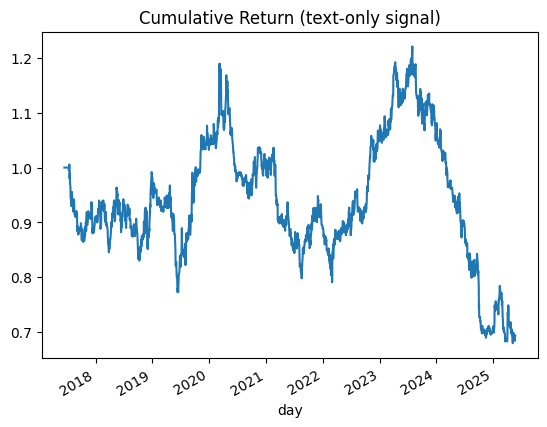

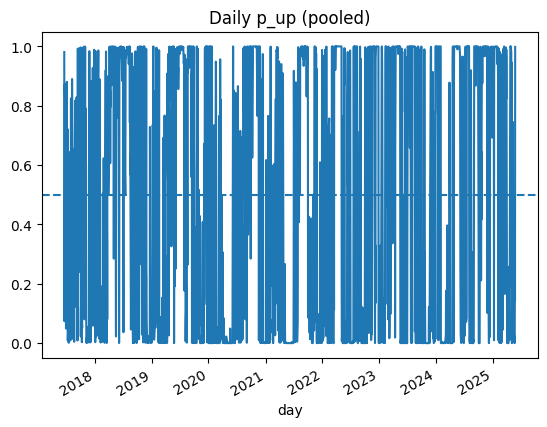

In [8]:
# ====== BLOCK 5: Prices → labels, metrics, minimal backtest ======

# ---- CONFIGURE PATHS ----
CFG["price_csv_path"]  = "/content/MOPS380_CI_SymbolPrice_2025-06-02T030407Z.csv"  # adjust if needed
CFG["price_date_col"]  = "Date"     # file uses "Bate,Close,High,Low" → we fix to Date
CFG["price_close_col"] = "Close"
CFG["epsilon_mode"]    = "sigma"    # {"abs","sigma"} dead-zone
CFG["epsilon_value"]   = 0.20       # 0.20 σ dead-zone
CFG["epsilon_window"]  = 60
CFG["abstain_band"]    = 0.05       # abstain if p in [0.5±band]
CFG["vol_target_daily"]= 0.01       # 1% daily vol
CFG["max_leverage"]    = 1.0

import numpy as np, pandas as pd
from sklearn.metrics import roc_auc_score, brier_score_loss
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# ---------- LOAD & CLEAN PRICES (supports your file format) ----------
def load_prices(path, date_col="Date", close_col="Close"):
    """
    Reads price CSVs that have 3 description lines and a header on line 4:
      1: Description, ...
      2: Currency/UOM, ...
      3: Symbol Code, ...
      4: Bate,Close,High,Low
      5+: YYYY-MM-DD,close,high,low

    Returns df with columns: day (datetime), close (float), sorted by day.
    """
    px = pd.read_csv(path, header=3)
    px.columns = [c.strip() for c in px.columns]
    if "Bate" in px.columns:
        px = px.rename(columns={"Bate": "Date"})
    # Case-insensitive safety
    cols_lower = {c.lower(): c for c in px.columns}
    if date_col not in px.columns and date_col.lower() in cols_lower:
        date_col = cols_lower[date_col.lower()]
    if close_col not in px.columns and close_col.lower() in cols_lower:
        close_col = cols_lower[close_col.lower()]
    px = px[[date_col, close_col]].copy()
    px.rename(columns={date_col: "day", close_col: "close"}, inplace=True)
    px["day"] = pd.to_datetime(px["day"], errors="coerce").dt.tz_localize(None)
    px = px.dropna(subset=["day", "close"]).sort_values("day").reset_index(drop=True)
    return px

# ---------- LABEL CONSTRUCTION ----------
def make_labels(px, eps_mode="sigma", eps_val=0.20, eps_win=60):
    """
    Label is based on next-day return ret1 = Close_{t+1}/Close_t - 1
    Dead-zone:
      - abs: |ret1| <= eps_val  → unlabeled (NaN)
      - sigma: |ret1| <= eps_val * rolling_std(ret1, eps_win) → unlabeled
    Output px has columns: day, close, ret1, _eps, y
    """
    px = px.copy()
    px["ret1"] = px["close"].pct_change().shift(-1)  # ret from t -> t+1
    if eps_mode == "abs":
        px["_eps"] = float(eps_val)
    else:
        rstd = px["ret1"].rolling(eps_win, min_periods=10).std()
        px["_eps"] = eps_val * rstd
    px["y"] = np.where(px["ret1"] > px["_eps"], 1,
                np.where(px["ret1"] < -px["_eps"], 0, np.nan))
    return px

# ---------- MERGE SIGNAL WITH LABELS ----------
def merge_signal_with_labels(sig, px):
    sig2 = sig.copy()
    sig2["day"] = pd.to_datetime(sig2["day"]).dt.tz_localize(None)
    return sig2.merge(px[["day","ret1","y"]], on="day", how="left")

# ---------- EVALUATION ----------
def eval_classification(dfm):
    out = {}
    m = dfm.dropna(subset=["p_up","y"])
    if len(m) >= 50 and m["y"].nunique() == 2:
        out["AUC"] = roc_auc_score(m["y"], m["p_up"])
        out["Brier"] = brier_score_loss(m["y"], m["p_up"])
        signed = m["y"].map({0:-1,1:1})
        out["IC_spearman"] = spearmanr(signed, m["p_up"]).statistic
    else:
        out["AUC"] = np.nan
        out["Brier"] = np.nan
        out["IC_spearman"] = np.nan
    return out

# ---------- MINIMAL BACKTEST ----------
def backtest_minimal(dfm, abstain_band=0.05, vol_target=0.01, max_leverage=1.0):
    """
    Sign strategy with abstention + volatility targeting on realized ret1.
    pos_raw ∈ {-1,0,1}; pos scaled by vol target with cap.
    Enter at close_t for ret_{t→t+1}.
    """
    d = dfm.copy()
    d["pos_raw"] = np.where(d["p_up"] >= 0.5 + abstain_band,  1,
                    np.where(d["p_up"] <= 0.5 - abstain_band, -1, 0))
    rstd = d["ret1"].rolling(60, min_periods=20).std()
    scale = (vol_target / rstd).clip(upper=max_leverage)
    d["pos"] = (d["pos_raw"] * scale).fillna(0.0)

    d["pnl"] = d["pos"].shift(1) * d["ret1"]
    d["cumret"] = (1.0 + d["pnl"].fillna(0)).cumprod()

    daily_pnl = d["pnl"].dropna()
    ann = 252
    mu  = daily_pnl.mean() * ann
    sig = daily_pnl.std()  * np.sqrt(ann)
    sharpe = (mu/sig) if sig and sig > 0 else np.nan

    return {
        "Sharpe_ann": sharpe,
        "AnnReturn":  mu,
        "AnnVol":     sig,
        "HitRate":    (daily_pnl>0).mean() if len(daily_pnl) else np.nan,
        "Turnover(avg abs Δpos)": (d["pos"].diff().abs().fillna(0)).mean(),
        "SelectedDays%": (d["pos_raw"]!=0).mean()
    }, d

# ---------- RUN PIPELINE ----------
# ensure daily_signal exists
if "daily_signal" not in globals():
    raise RuntimeError("daily_signal not found. Run Blocks 2–4 first.")

# 1) Load prices
px = load_prices(CFG["price_csv_path"], CFG["price_date_col"], CFG["price_close_col"])

# 2) Build labels
px = make_labels(px, CFG["epsilon_mode"], CFG["epsilon_value"], CFG["epsilon_window"])

# 3) Merge with signal
dfm = merge_signal_with_labels(daily_signal, px)

print("Rows with valid labels:", int(dfm["y"].notna().sum()), "/", len(dfm))
display(dfm[["day","p_up","n_headlines","ret1","y"]].head(10))

# 4) Classification metrics
cls_metrics = eval_classification(dfm)
print("Classification metrics:", cls_metrics)

# 5) Minimal backtest
bt_metrics, bt_df = backtest_minimal(
    dfm,
    abstain_band=CFG["abstain_band"],
    vol_target=CFG["vol_target_daily"],
    max_leverage=CFG["max_leverage"]
)
print("Backtest metrics:", bt_metrics)

# 6) Save merged + equity series
dfm.to_csv("daily_text_signal_with_labels.csv", index=False)
bt_df[["day","cumret","pos","pos_raw","pnl"]].to_csv("bt_text_signal_equity.csv", index=False)
print("Saved: daily_text_signal_with_labels.csv, bt_text_signal_equity.csv")

# 7) Quick plots
plt.figure()
bt_df.set_index("day")["cumret"].plot(title="Cumulative Return (text-only signal)")
plt.show()

plt.figure()
dfm.set_index("day")["p_up"].plot(title="Daily p_up (pooled)")
plt.axhline(0.5, linestyle="--")
plt.show()


Total unique days: 1980 | lookback=365d | retrain_cadence=30d
[50/1980] 2017-08-25 | headlines=79 | p_up=0.559
[100/1980] 2017-11-07 | headlines=85 | p_up=0.640
[150/1980] 2018-01-18 | headlines=59 | p_up=0.623
[200/1980] 2018-04-03 | headlines=41 | p_up=0.583
[250/1980] 2018-06-14 | headlines=64 | p_up=0.607
[300/1980] 2018-08-28 | headlines=52 | p_up=0.530
[350/1980] 2018-11-07 | headlines=88 | p_up=0.550
[400/1980] 2019-01-18 | headlines=49 | p_up=0.540
[450/1980] 2019-04-02 | headlines=62 | p_up=0.531
[500/1980] 2019-06-14 | headlines=53 | p_up=0.533
[550/1980] 2019-08-27 | headlines=56 | p_up=0.641
[600/1980] 2019-11-06 | headlines=52 | p_up=0.492
[650/1980] 2020-01-21 | headlines=1 | p_up=0.534
[700/1980] 2020-04-03 | headlines=22 | p_up=0.424
[750/1980] 2020-06-17 | headlines=46 | p_up=0.500
[800/1980] 2020-08-31 | headlines=24 | p_up=0.492
[850/1980] 2020-11-09 | headlines=34 | p_up=0.468
[900/1980] 2021-01-20 | headlines=40 | p_up=0.508
[950/1980] 2021-04-01 | headlines=36 | p

,day,p_up,n_headlines,ret1,y
0,2017-06-15,NaN,0,0.004403,1.0
1,2017-06-16,NaN,0,0.003822,1.0
2,2017-06-19,NaN,0,0.000279,NaN
3,2017-06-20,NaN,0,-0.018789,0.0
4,2017-06-21,NaN,0,-0.011995,0.0
5,2017-06-22,0.336729,57,0.010339,1.0
6,2017-06-23,0.405209,44,0.016580,1.0
7,2017-06-27,0.464546,68,0.003437,1.0
8,2017-06-28,0.399776,57,0.016254,1.0
9,2017-06-29,0.339697,58,0.012382,1.0


{'AUC': np.float64(0.5079318999667363), 'Brier': np.float64(0.2522911045210168), 'IC_spearman': np.float64(0.013700625840465231)}
Backtest metrics (true-label training): {'Sharpe_ann': np.float64(0.04389117869257686), 'AnnReturn': np.float64(0.005650191231211232), 'AnnVol': np.float64(0.1287318180900625), 'HitRate': np.float64(0.2769620253164557), 'Turnover(avg abs Δpos)': np.float64(0.09981912856924312), 'SelectedDays%': np.float64(0.544949494949495)}
Saved: daily_text_signal_true.csv, daily_text_signal_true_with_labels.csv, bt_text_signal_true_equity.csv


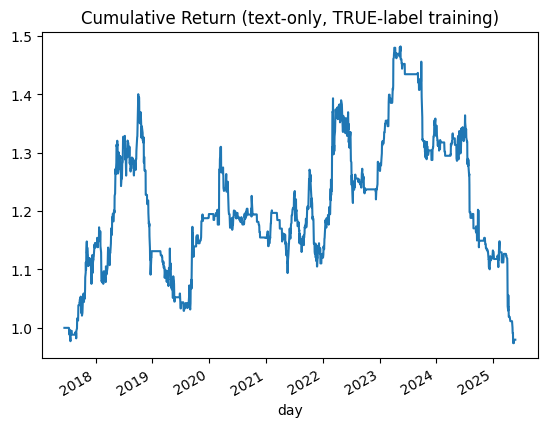

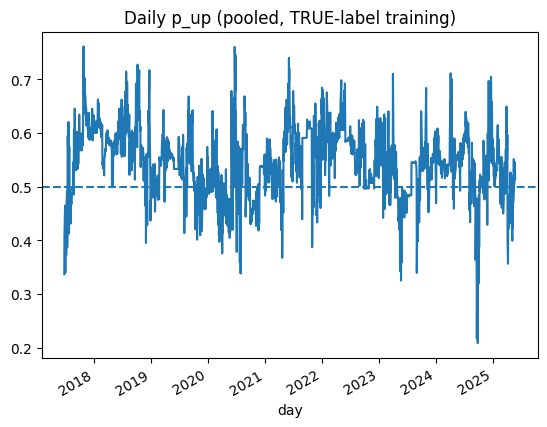

In [9]:
# ====== BLOCK 6: Rolling TRUE-LABEL training (headline-level) ======
# Trains on historical headlines whose day-label (from prices) is known (and not in the dead-zone),
# predicts per-headline p_up for each day, then pools into a daily p_up.

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, brier_score_loss
from scipy.special import logit, expit
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# ---------------- safety: ensure prices + labels exist ----------------
if "px" not in globals():
    # Use the Block-5 helpers if present; otherwise define minimal loader here
    try:
        px = load_prices(CFG["price_csv_path"], CFG["price_date_col"], CFG["price_close_col"])
    except NameError:
        # Minimal fallback for your specific file format (3 preface lines)
        def _fallback_load_prices(path, date_col="Date", close_col="Close"):
            p = pd.read_csv(path, header=3)
            p.columns = [c.strip() for c in p.columns]
            if "Bate" in p.columns: p = p.rename(columns={"Bate":"Date"})
            m = {c.lower(): c for c in p.columns}
            date_col = m.get(date_col.lower(), date_col)
            close_col = m.get(close_col.lower(), close_col)
            p = p[[date_col, close_col]].rename(columns={date_col:"day", close_col:"close"})
            p["day"] = pd.to_datetime(p["day"], errors="coerce").dt.tz_localize(None)
            return p.dropna(subset=["day","close"]).sort_values("day").reset_index(drop=True)
        px = _fallback_load_prices(CFG["price_csv_path"], CFG["price_date_col"], CFG["price_close_col"])

if "make_labels" in globals():
    px_lab = make_labels(px, CFG["epsilon_mode"], CFG["epsilon_value"], CFG["epsilon_window"])
else:
    # Minimal labeler if Block-5 helpers missing
    def _fallback_make_labels(pxt, eps_mode="sigma", eps_val=0.20, eps_win=60):
        p = pxt.copy()
        p["ret1"] = p["close"].pct_change().shift(-1)
        if eps_mode == "abs":
            p["_eps"] = float(eps_val)
        else:
            rstd = p["ret1"].rolling(eps_win, min_periods=10).std()
            p["_eps"] = eps_val * rstd
        p["y"] = np.where(p["ret1"] > p["_eps"], 1,
                   np.where(p["ret1"] < -p["_eps"], 0, np.nan))
        return p
    px_lab = _fallback_make_labels(px, CFG["epsilon_mode"], CFG["epsilon_value"], CFG["epsilon_window"])

# Map day -> true label y (NaN = dead-zone) and ret1
day_to_y    = px_lab.set_index("day")["y"]
day_to_ret1 = px_lab.set_index("day")["ret1"]

# ---------------- utilities ----------------
def pool_probs(probs, method="logit_mean", top_m=5):
    probs = np.asarray(probs, dtype=float)
    if probs.size == 0:
        return np.nan
    if method == "mean":
        return float(probs.mean())
    if method == "logit_mean":
        p = np.clip(probs, 1e-6, 1-1e-6)
        return float(expit(np.mean(logit(p))))
    if method == "top_m":
        m = min(top_m, probs.size)
        return float(np.sort(probs)[-m:].mean())
    raise ValueError("Unknown pooling method")

def fit_vectorizer(corpus, min_df=3, ngram_range=(1,2)):
    return TfidfVectorizer(
        min_df=min_df,
        ngram_range=ngram_range,
        token_pattern=r"(?u)\b\w[\w\-/\.]+\b"
    )

def fit_model(X, y, C=2.0):
    base = LogisticRegression(
        C=C, solver="liblinear",
        class_weight="balanced", max_iter=200
    )
    # Calibrate on internal CV to improve probability quality
    clf = CalibratedClassifierCV(base, cv=3, method="isotonic")
    clf.fit(X, y)
    return clf

# ---------------- config (can be tuned) ----------------
LOOKBACK_DAYS       = int(CFG.get("rolling_vocab_lookback_days", 365))   # training window length
RETRAIN_CADENCE     = int(CFG.get("retrain_cadence_days", 30))           # retrain every N days
MIN_DF              = int(CFG.get("min_df", 3))
NGRAM_RANGE         = tuple(CFG.get("ngram_range", (1,2)))
C_VAL               = float(CFG.get("C", 2.0))
POOLING             = CFG.get("pooling", "logit_mean")
TOP_M               = int(CFG.get("top_m", 5))

USE_MASKED_TEXT     = bool(CFG.get("mask_company_tokens", True) or CFG.get("mask_location_tokens", True))
TEXT_SERIES_NAME    = "_text_masked" if USE_MASKED_TEXT and "_text_masked" in df.columns else text_col

# ---------------- walk-forward over days ----------------
all_days = np.array(sorted(df["_bucket_day"].unique()))
daily_scores_true = []

vec = None
clf = None
last_retrain_day = None

print(f"Total unique days: {len(all_days)} | lookback={LOOKBACK_DAYS}d | retrain_cadence={RETRAIN_CADENCE}d")
for i, day in enumerate(all_days, 1):
    train_end   = pd.Timestamp(day) - pd.Timedelta(days=1)
    train_start = train_end - pd.Timedelta(days=LOOKBACK_DAYS)

    # Build headline-level training set by joining each headline to its day's label (true label)
    mask_hist = (df["_bucket_day"] >= train_start) & (df["_bucket_day"] <= train_end)
    d_hist = df.loc[mask_hist, [TEXT_SERIES_NAME, "_bucket_day"]].copy()
    if d_hist.empty:
        daily_scores_true.append({"day": day, "p_up": np.nan, "n_headlines": 0})
        continue

    # Assign labels per headline from that day's price label
    d_hist["y"] = d_hist["_bucket_day"].map(day_to_y)
    # Drop unlabeled (dead-zone) and NaN
    d_hist = d_hist.dropna(subset=["y"])
    if len(d_hist) < 200:  # need enough samples to fit/calibrate
        daily_scores_true.append({"day": day, "p_up": np.nan, "n_headlines": 0})
        if i % 50 == 0:
            print(f"[{i}/{len(all_days)}] {day.date()} | too few labeled headlines in history ({len(d_hist)}) → skip")
        continue

    # Retrain on cadence or if model uninitialized
    need_retrain = (clf is None) or (last_retrain_day is None) or ((day - last_retrain_day).days >= RETRAIN_CADENCE)
    if need_retrain:
        trn_text = d_hist[TEXT_SERIES_NAME].astype(str).tolist()
        vec = fit_vectorizer(trn_text, MIN_DF, NGRAM_RANGE)
        X_trn = vec.fit_transform(trn_text)
        y_trn = d_hist["y"].astype(int).values
        clf = fit_model(X_trn, y_trn, C_VAL)
        last_retrain_day = pd.Timestamp(day)

    # Score today's headlines
    d_today = df.loc[df["_bucket_day"] == day, [TEXT_SERIES_NAME]].copy()
    if len(d_today) == 0:
        daily_scores_true.append({"day": day, "p_up": np.nan, "n_headlines": 0})
        continue

    X_tst = vec.transform(d_today[TEXT_SERIES_NAME].astype(str).tolist())
    p_i   = clf.predict_proba(X_tst)[:, 1]
    p_day = pool_probs(p_i, method=POOLING, top_m=TOP_M)

    daily_scores_true.append({
        "day": day,
        "p_up": float(p_day),
        "n_headlines": int(len(d_today))
    })

    if i % 50 == 0:
        print(f"[{i}/{len(all_days)}] {day.date()} | headlines={len(d_today)} | p_up={p_day:.3f}")

daily_signal_true = pd.DataFrame(daily_scores_true).sort_values("day").reset_index(drop=True)

# ---------------- merge with labels and evaluate ----------------
dfm_true = daily_signal_true.copy()
dfm_true["day"] = pd.to_datetime(dfm_true["day"]).dt.tz_localize(None)
dfm_true["ret1"] = dfm_true["day"].map(day_to_ret1)
dfm_true["y"]    = dfm_true["day"].map(day_to_y)

print("Rows with valid labels:", int(dfm_true["y"].notna().sum()), "/", len(dfm_true))
display(dfm_true[["day","p_up","n_headlines","ret1","y"]].head(10))

m = dfm_true.dropna(subset=["p_up","y"])
if len(m) >= 50 and m["y"].nunique() == 2:
    auc   = roc_auc_score(m["y"], m["p_up"])
    brier = brier_score_loss(m["y"], m["p_up"])
    ic    = spearmanr(m["y"].map({0:-1,1:1}), m["p_up"]).statistic
else:
    auc = brier = ic = np.nan

print({"AUC": auc, "Brier": brier, "IC_spearman": ic})

# ---------------- minimal backtest (reuse Block-5 function if present) ----------------
if "backtest_minimal" in globals():
    bt_metrics_true, bt_df_true = backtest_minimal(
        dfm_true,
        abstain_band=CFG["abstain_band"],
        vol_target=CFG["vol_target_daily"],
        max_leverage=CFG["max_leverage"]
    )
else:
    # tiny fallback (no change to logic)
    def _fallback_backtest(dfm, abstain_band=0.05, vol_target=0.01, max_leverage=1.0):
        d = dfm.copy()
        d["pos_raw"] = np.where(d["p_up"] >= 0.5 + abstain_band,  1,
                        np.where(d["p_up"] <= 0.5 - abstain_band, -1, 0))
        rstd = d["ret1"].rolling(60, min_periods=20).std()
        scale = (vol_target / rstd).clip(upper=max_leverage)
        d["pos"] = (d["pos_raw"] * scale).fillna(0.0)
        d["pnl"] = d["pos"].shift(1) * d["ret1"]
        d["cumret"] = (1.0 + d["pnl"].fillna(0)).cumprod()
        ann = 252
        pnl = d["pnl"].dropna()
        mu  = pnl.mean()*ann
        sig = pnl.std()*np.sqrt(ann)
        sharpe = (mu/sig) if sig and sig>0 else np.nan
        return {
            "Sharpe_ann": sharpe, "AnnReturn": mu, "AnnVol": sig,
            "HitRate": (pnl>0).mean() if len(pnl) else np.nan,
            "Turnover(avg abs Δpos)": (d["pos"].diff().abs().fillna(0)).mean(),
            "SelectedDays%": (d["pos_raw"]!=0).mean()
        }, d
    bt_metrics_true, bt_df_true = _fallback_backtest(
        dfm_true,
        abstain_band=CFG["abstain_band"],
        vol_target=CFG["vol_target_daily"],
        max_leverage=CFG["max_leverage"]
    )

print("Backtest metrics (true-label training):", bt_metrics_true)

# ---------------- persist + quick plots ----------------
daily_signal_true.to_csv("daily_text_signal_true.csv", index=False)
dfm_true.to_csv("daily_text_signal_true_with_labels.csv", index=False)
bt_df_true[["day","cumret","pos","pos_raw","pnl"]].to_csv("bt_text_signal_true_equity.csv", index=False)
print("Saved: daily_text_signal_true.csv, daily_text_signal_true_with_labels.csv, bt_text_signal_true_equity.csv")

plt.figure()
bt_df_true.set_index("day")["cumret"].plot(title="Cumulative Return (text-only, TRUE-label training)")
plt.show()

plt.figure()
dfm_true.set_index("day")["p_up"].plot(title="Daily p_up (pooled, TRUE-label training)")
plt.axhline(0.5, linestyle="--")
plt.show()



=== Run 1/16 | pooling=logit_mean | retrain=30d | abstain=±0.05 | eps=0.1σ ===

=== Run 2/16 | pooling=logit_mean | retrain=30d | abstain=±0.05 | eps=0.2σ ===

=== Run 3/16 | pooling=logit_mean | retrain=30d | abstain=±0.1 | eps=0.1σ ===

=== Run 4/16 | pooling=logit_mean | retrain=30d | abstain=±0.1 | eps=0.2σ ===

=== Run 5/16 | pooling=logit_mean | retrain=90d | abstain=±0.05 | eps=0.1σ ===

=== Run 6/16 | pooling=logit_mean | retrain=90d | abstain=±0.05 | eps=0.2σ ===

=== Run 7/16 | pooling=logit_mean | retrain=90d | abstain=±0.1 | eps=0.1σ ===

=== Run 8/16 | pooling=logit_mean | retrain=90d | abstain=±0.1 | eps=0.2σ ===

=== Run 9/16 | pooling=top_m | retrain=30d | abstain=±0.05 | eps=0.1σ ===

=== Run 10/16 | pooling=top_m | retrain=30d | abstain=±0.05 | eps=0.2σ ===

=== Run 11/16 | pooling=top_m | retrain=30d | abstain=±0.1 | eps=0.1σ ===

=== Run 12/16 | pooling=top_m | retrain=30d | abstain=±0.1 | eps=0.2σ ===

=== Run 13/16 | pooling=top_m | retrain=90d | abstain=±0.05 | 

,pooling,retrain,abstain,eps_k,AUC,Brier,IC,Sharpe_ann,AnnReturn,AnnVol,HitRate,Turnover(avg abs Δpos),SelectedDays%,Selected%,n_labeled
0,top_m,90,0.05,0.2,0.489910,0.262359,-0.017428,0.276368,0.041437,0.149934,0.407595,0.040350,0.768687,0.768687,1635
1,top_m,30,0.05,0.1,0.504173,0.260080,0.007212,0.239421,0.035111,0.146651,0.375696,0.052446,0.721212,0.721212,1788
2,top_m,30,0.05,0.2,0.508351,0.260577,0.014425,0.217431,0.032530,0.149611,0.394937,0.048779,0.757071,0.757071,1635
3,top_m,90,0.05,0.1,0.490293,0.263024,-0.016776,0.208163,0.029595,0.142171,0.371139,0.040571,0.716162,0.716162,1788
4,top_m,30,0.10,0.2,0.508351,0.260577,0.014425,0.083351,0.010157,0.121860,0.270380,0.085445,0.524242,0.524242,1635
5,logit_mean,30,0.05,0.1,0.507766,0.251864,0.013421,0.081148,0.010088,0.124319,0.263291,0.107534,0.514646,0.514646,1788
6,top_m,30,0.10,0.1,0.504173,0.260080,0.007212,0.064987,0.007427,0.114283,0.246076,0.091233,0.479798,0.479798,1788
7,logit_mean,30,0.05,0.2,0.507932,0.252291,0.013701,0.043891,0.005650,0.128732,0.276962,0.099819,0.544949,0.544949,1635
8,top_m,90,0.10,0.1,0.490293,0.263024,-0.016776,0.036258,0.003895,0.107435,0.224304,0.092358,0.440909,0.440909,1788
9,top_m,90,0.10,0.2,0.489910,0.262359,-0.017428,-0.031162,-0.003539,0.113553,0.238481,0.082226,0.462626,0.462626,1635


Saved: text_signal_ablation_results.csv
Best config: {'pooling': 'top_m', 'retrain': 90, 'abstain': 0.05, 'eps_k': 0.2, 'AUC': np.float64(0.48991049018718436), 'Brier': np.float64(0.2623591725354073), 'IC': np.float64(-0.01742820238783918), 'Sharpe_ann': np.float64(0.27636819406340457), 'AnnReturn': np.float64(0.04143691656199095), 'AnnVol': np.float64(0.1499337385852891), 'HitRate': np.float64(0.40759493670886077), 'Turnover(avg abs Δpos)': np.float64(0.040349552087467044), 'SelectedDays%': np.float64(0.7686868686868686), 'Selected%': np.float64(0.7686868686868686), 'n_labeled': 1635}
Saved: text_signal_rolling_metrics_252d.csv


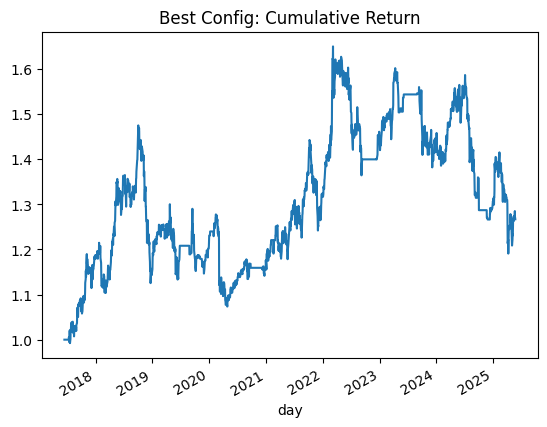

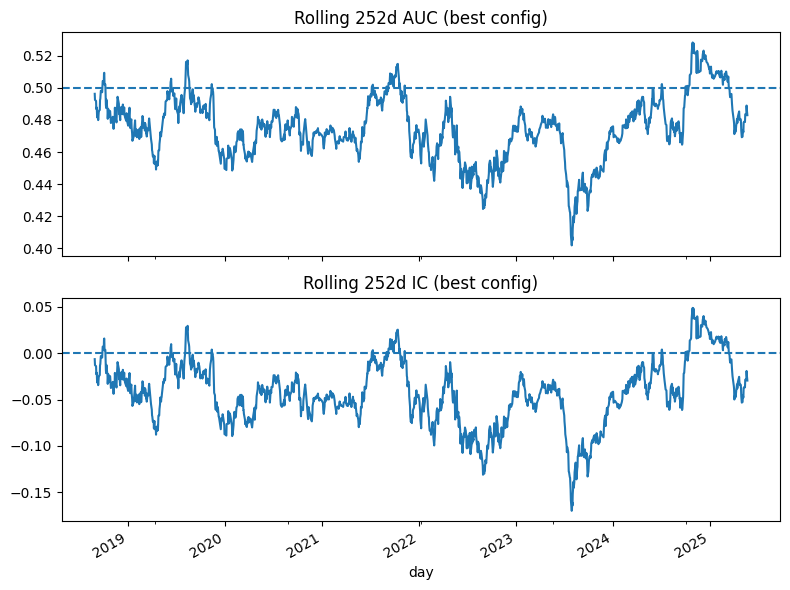

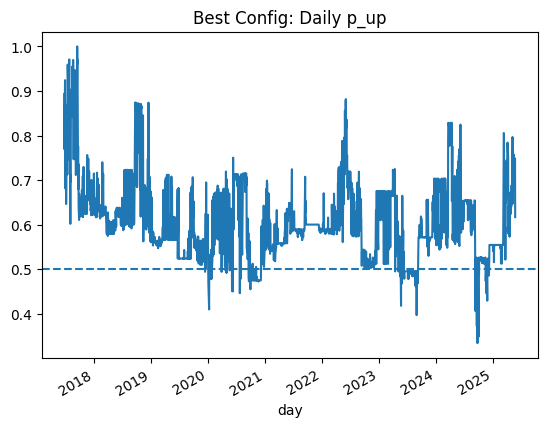

Saved: daily_text_signal_true_best.csv


In [10]:
# ====== BLOCK 7: Hyperparameter ablations + rolling diagnostics ======
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, brier_score_loss
from scipy.special import logit, expit
from scipy.stats import spearmanr

# -------- helpers reused --------
def pool_probs(probs, method="logit_mean", top_m=5):
    p = np.asarray(probs, float)
    if p.size == 0: return np.nan
    if method == "mean":       return float(p.mean())
    if method == "logit_mean": return float(expit(np.mean(logit(np.clip(p,1e-6,1-1e-6)))))
    if method == "top_m":      return float(np.sort(p)[-min(top_m, len(p)):].mean())
    raise ValueError("Unknown pooling")

def fit_vectorizer(corpus, min_df=3, ngram_range=(1,2)):
    return TfidfVectorizer(min_df=min_df, ngram_range=ngram_range, token_pattern=r"(?u)\b\w[\w\-/\.]+\b")

def fit_model(X, y, C=2.0):
    base = LogisticRegression(C=C, solver="liblinear", class_weight="balanced", max_iter=200)
    clf = CalibratedClassifierCV(base, cv=3, method="isotonic")
    clf.fit(X, y)
    return clf

def make_labels_sigma(px, k=0.20, win=60):
    p = px.copy()
    p["ret1"] = p["close"].pct_change().shift(-1)
    rstd = p["ret1"].rolling(win, min_periods=10).std()
    p["_eps"] = k * rstd
    p["y"] = np.where(p["ret1"] > p["_eps"], 1, np.where(p["ret1"] < -p["_eps"], 0, np.nan))
    return p

def rolling_metrics(dfm, window=252):
    """Rolling AUC/IC on labeled days; returns a DataFrame indexed by day."""
    out = []
    m = dfm.dropna(subset=["p_up","y"]).copy()
    m = m.sort_values("day")
    for i in range(window, len(m)+1):
        w = m.iloc[i-window:i]
        if w["y"].nunique() < 2:
            out.append((w["day"].iloc[-1], np.nan, np.nan))
            continue
        auc = roc_auc_score(w["y"], w["p_up"])
        ic  = spearmanr(w["y"].map({0:-1,1:1}), w["p_up"]).statistic
        out.append((w["day"].iloc[-1], auc, ic))
    r = pd.DataFrame(out, columns=["day","AUC_roll","IC_roll"])
    return r

# -------- core runner: true-label walk-forward with knobs --------
def run_true_signal(
    px_lab,                       # price+labels df from Block 5/6 (columns: day, close, ret1, y)
    lookback_days=365,
    retrain_cadence_days=30,
    min_df=3,
    ngram_range=(1,2),
    C_val=2.0,
    pooling="logit_mean",
    top_m=5,
    abstain_band=0.05,
):
    # label maps
    day_to_y    = px_lab.set_index("day")["y"]
    day_to_ret1 = px_lab.set_index("day")["ret1"]

    USE_MASKED_TEXT  = bool(CFG.get("mask_company_tokens", True) or CFG.get("mask_location_tokens", True))
    TEXT_SERIES_NAME = "_text_masked" if USE_MASKED_TEXT and "_text_masked" in df.columns else text_col

    all_days = np.array(sorted(df["_bucket_day"].unique()))
    daily = []

    vec = clf = None
    last_retrain = None

    for i, day in enumerate(all_days, 1):
        train_end   = pd.Timestamp(day) - pd.Timedelta(days=1)
        train_start = train_end - pd.Timedelta(days=lookback_days)

        hist = df.loc[(df["_bucket_day"] >= train_start) & (df["_bucket_day"] <= train_end),
                      [TEXT_SERIES_NAME, "_bucket_day"]].copy()
        if hist.empty:
            daily.append({"day": day, "p_up": np.nan, "n_headlines": 0})
            continue

        hist["y"] = hist["_bucket_day"].map(day_to_y)
        hist = hist.dropna(subset=["y"])
        if len(hist) < 200:
            daily.append({"day": day, "p_up": np.nan, "n_headlines": 0})
            continue

        need_retrain = (clf is None) or (last_retrain is None) or ((day - last_retrain).days >= retrain_cadence_days)
        if need_retrain:
            t = hist[TEXT_SERIES_NAME].astype(str).tolist()
            vec = fit_vectorizer(t, min_df=min_df, ngram_range=ngram_range)
            X   = vec.fit_transform(t)
            y   = hist["y"].astype(int).values
            clf = fit_model(X, y, C_val)
            last_retrain = pd.Timestamp(day)

        today = df.loc[df["_bucket_day"] == day, [TEXT_SERIES_NAME]].copy()
        if len(today) == 0:
            daily.append({"day": day, "p_up": np.nan, "n_headlines": 0})
            continue

        X_t  = vec.transform(today[TEXT_SERIES_NAME].astype(str).tolist())
        p_i  = clf.predict_proba(X_t)[:, 1]
        p_d  = pool_probs(p_i, method=pooling, top_m=top_m)
        daily.append({"day": day, "p_up": float(p_d), "n_headlines": int(len(today))})

    sig = pd.DataFrame(daily).sort_values("day").reset_index(drop=True)
    dfm = sig.copy()
    dfm["day"]   = pd.to_datetime(dfm["day"]).dt.tz_localize(None)
    dfm["ret1"]  = dfm["day"].map(day_to_ret1)
    dfm["y"]     = dfm["day"].map(day_to_y)

    # classification metrics
    m = dfm.dropna(subset=["p_up","y"])
    if len(m) >= 50 and m["y"].nunique()==2:
        auc   = roc_auc_score(m["y"], m["p_up"])
        brier = brier_score_loss(m["y"], m["p_up"])
        ic    = spearmanr(m["y"].map({0:-1,1:1}), m["p_up"]).statistic
    else:
        auc = brier = ic = np.nan

    # backtest
    bt_metrics, bt_df = backtest_minimal(dfm, abstain_band=abstain_band,
                                         vol_target=CFG["vol_target_daily"],
                                         max_leverage=CFG["max_leverage"])

    return {
        "AUC": auc,
        "Brier": brier,
        "IC": ic,
        **bt_metrics,
        "Selected%": bt_metrics["SelectedDays%"],
        "n_labeled": int(dfm["y"].notna().sum())
    }, dfm, bt_df, sig

# --------- small, fast grid (kept tight to finish quickly) ---------
grid = []
for pooling in ["logit_mean", "top_m"]:
    for retrain in [30, 90]:
        for abstain in [0.05, 0.10]:
            for eps_k in [0.10, 0.20]:  # ε = k·σ
                grid.append(dict(pooling=pooling, retrain=retrain, abstain=abstain, eps_k=eps_k))

results = []
best = None
best_artifacts = None

for i, g in enumerate(grid, 1):
    print(f"\n=== Run {i}/{len(grid)} | pooling={g['pooling']} | retrain={g['retrain']}d | abstain=±{g['abstain']} | eps={g['eps_k']}σ ===")
    # rebuild labels for this epsilon
    px_lab_g = make_labels_sigma(px, k=g["eps_k"], win=int(CFG.get("epsilon_window", 60)))
    metrics, dfm_g, bt_g, sig_g = run_true_signal(
        px_lab_g,
        lookback_days=int(CFG.get("rolling_vocab_lookback_days", 365)),
        retrain_cadence_days=g["retrain"],
        min_df=int(CFG.get("min_df", 3)),
        ngram_range=tuple(CFG.get("ngram_range", (1,2))),
        C_val=float(CFG.get("C", 2.0)),
        pooling=g["pooling"],
        top_m=int(CFG.get("top_m", 5)),
        abstain_band=g["abstain"]
    )
    row = dict(**g, **metrics)
    results.append(row)

    # keep best by Sharpe, then AUC
    if best is None or (metrics["Sharpe_ann"], metrics["AUC"]) > (best["Sharpe_ann"], best["AUC"]):
        best = row
        best_artifacts = (dfm_g, bt_g, sig_g)

res_df = pd.DataFrame(results).sort_values(["Sharpe_ann","AUC"], ascending=[False, False]).reset_index(drop=True)
display(res_df.head(10))

# save results
res_df.to_csv("text_signal_ablation_results.csv", index=False)
print("Saved: text_signal_ablation_results.csv")
print("Best config:", best)

# --------- rolling diagnostics for the best config ---------
dfm_best, bt_best, sig_best = best_artifacts

roll = rolling_metrics(dfm_best, window=252)
roll.to_csv("text_signal_rolling_metrics_252d.csv", index=False)
print("Saved: text_signal_rolling_metrics_252d.csv")

plt.figure()
bt_best.set_index("day")["cumret"].plot(title="Best Config: Cumulative Return")
plt.show()

fig, ax = plt.subplots(2, 1, figsize=(8,6), sharex=True)
roll.set_index("day")["AUC_roll"].plot(ax=ax[0], title="Rolling 252d AUC (best config)")
ax[0].axhline(0.5, linestyle="--")
roll.set_index("day")["IC_roll"].plot(ax=ax[1], title="Rolling 252d IC (best config)")
ax[1].axhline(0.0, linestyle="--")
plt.tight_layout(); plt.show()

plt.figure()
dfm_best.set_index("day")["p_up"].plot(title="Best Config: Daily p_up")
plt.axhline(0.5, linestyle="--")
plt.show()

# Also dump best daily signal for reference
sig_best.to_csv("daily_text_signal_true_best.csv", index=False)
print("Saved: daily_text_signal_true_best.csv")


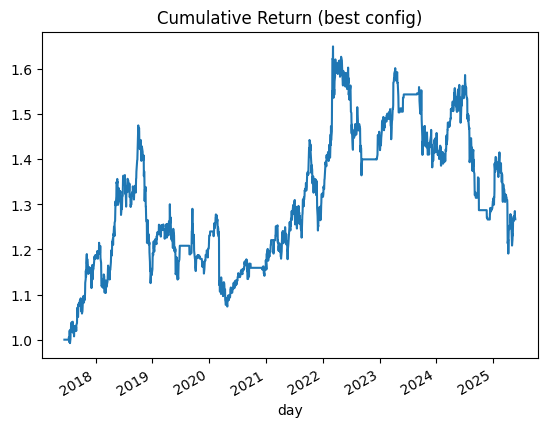

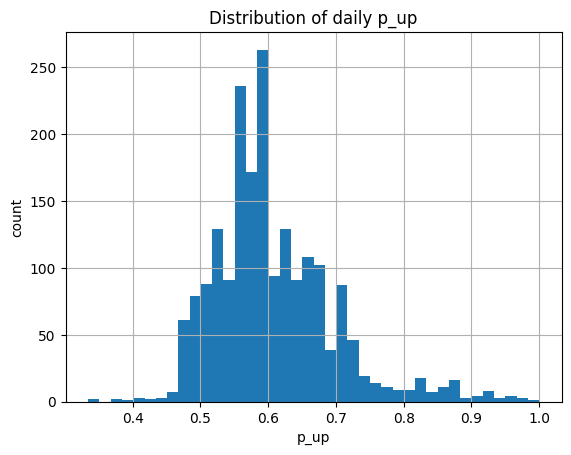

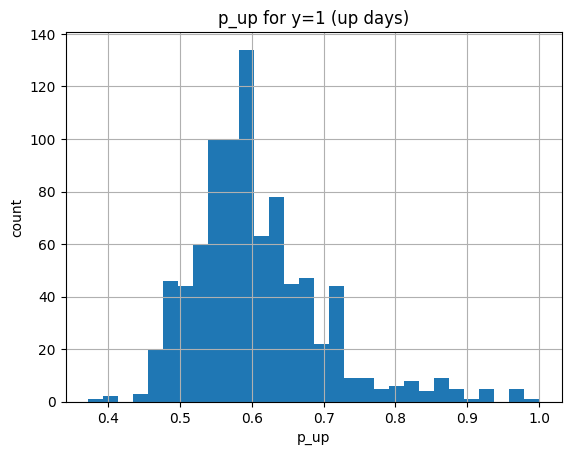

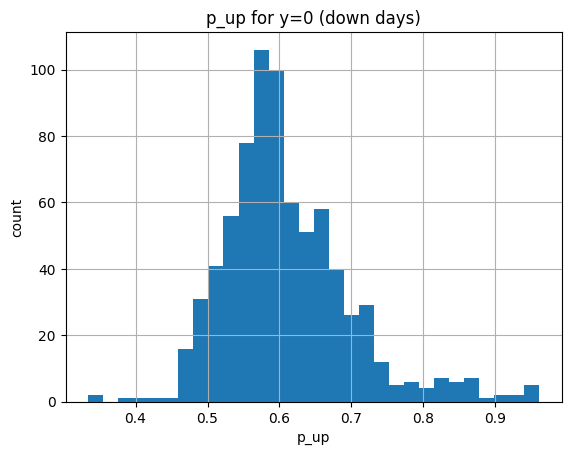

Calibration bins (avg predicted vs empirical 1-rate):


,bin,avg_pred,empirical
0,1,0.358367,0.250000
1,2,0.482647,0.590164
2,3,0.557893,0.540107
3,4,0.639115,0.511236
4,5,0.728298,0.563758
5,6,0.846959,0.566038
6,7,0.941827,0.571429


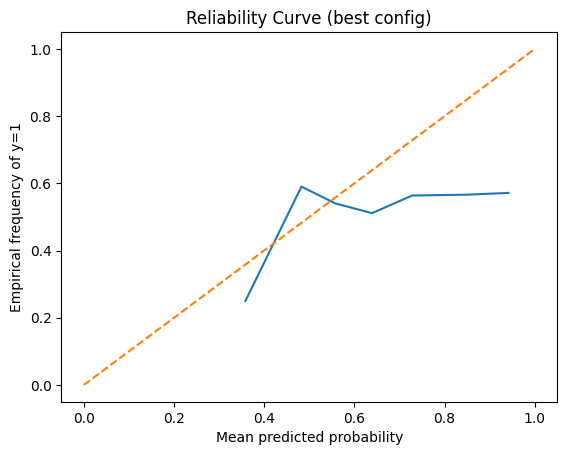

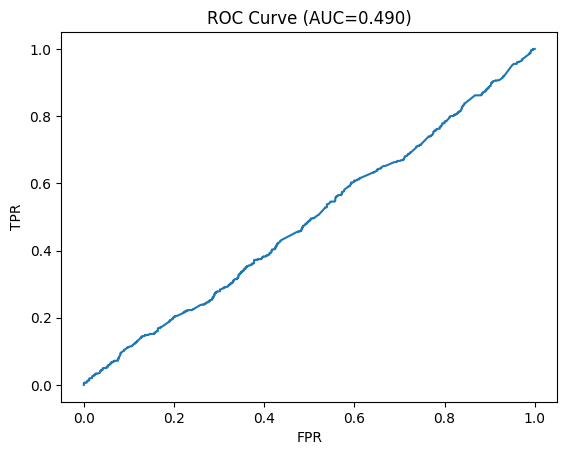

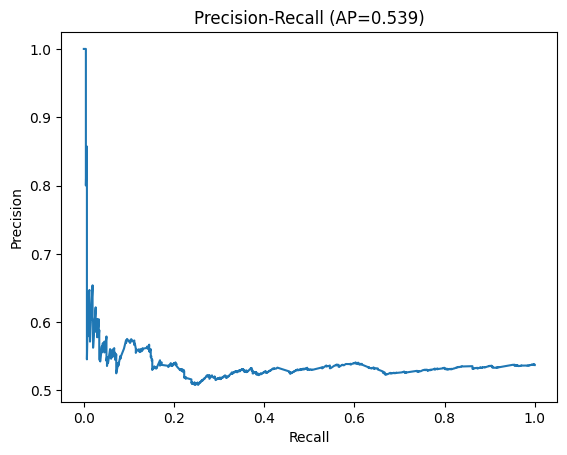

Decile table (by p_up):


,decile,mean_ret1,hit_rate,count
0,1,0.004010,0.554878,164
1,2,0.001765,0.563953,172
2,3,0.003049,0.577922,154
3,4,-0.004796,0.435583,163
4,5,0.002698,0.576687,163
5,6,0.004466,0.570552,163
6,7,-0.002668,0.533742,163
7,8,-0.000565,0.478528,163
8,9,-0.000856,0.506024,166
9,10,0.001554,0.575000,160


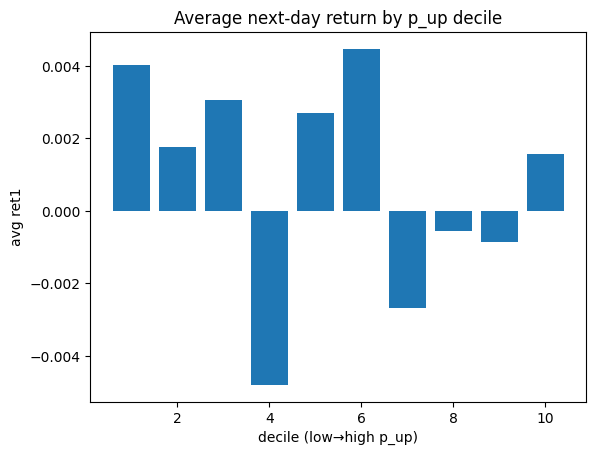

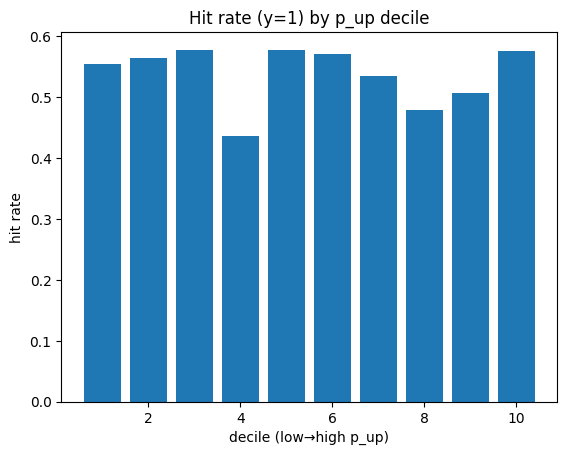

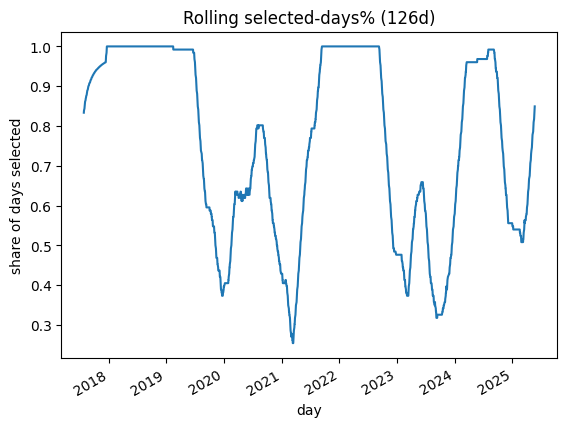

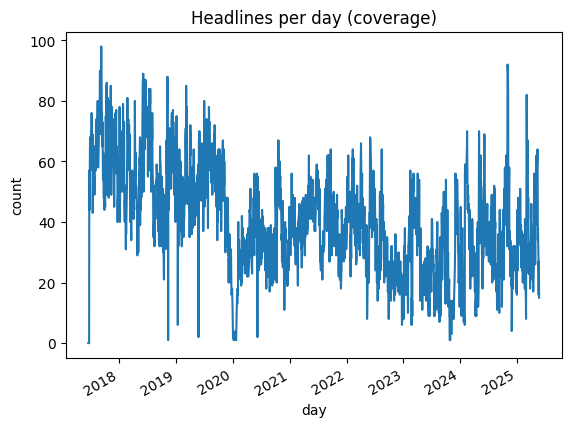

Top positive tokens (predict up):


,term,coef
24,mnth jun,2.502764
23,jan,2.274441
22,24-nov 28,2.260931
20,nov 24-nov,2.260931
21,24-nov,2.260931
19,offer oct,2.218317
18,27-mar 31,1.997859
17,mar 27-mar,1.997859
16,cpy 11,1.996968
15,incoterm,1.967196


Top negative tokens (predict down):


,term,coef
0,offer apr,-2.918488
1,26-nov 30,-2.660711
2,nov 26-nov,-2.660711
3,26-nov,-2.660711
4,24 100,-2.380339
5,24-jun 28,-2.278176
6,jun 24-jun,-2.278176
7,24-jun,-2.278176
8,23 100,-2.155568
9,24,-2.066273


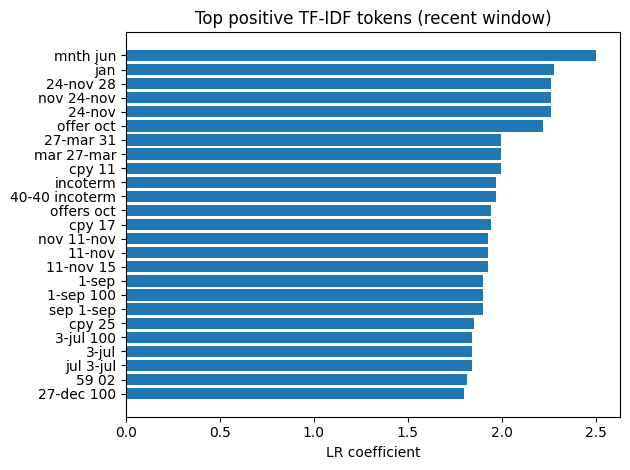

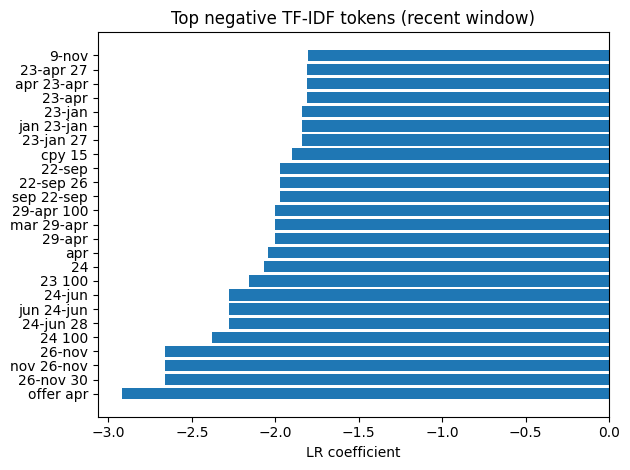

In [13]:
# ====== BLOCK 9: Visualizations for current TF-IDF LR model (from Block 7) ======
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score
from sklearn.calibration import calibration_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# --- load best artifacts (from memory or CSV) ---
try:
    dfm_best  # from Block 7
    bt_best
    sig_best
except NameError:
    dfm_best = pd.read_csv("daily_text_signal_true_best.csv", parse_dates=["day"])
    # If Block 7 didn't save bt_best, reconstruct minimal equity using backtest_minimal:
    if "backtest_minimal" in globals():
        metrics_tmp, bt_best = backtest_minimal(dfm_best,
                                                abstain_band=CFG["abstain_band"],
                                                vol_target=CFG["vol_target_daily"],
                                                max_leverage=CFG["max_leverage"])
    else:
        # minimal fallback
        d = dfm_best.copy()
        band = float(CFG.get("abstain_band", 0.05))
        d["pos_raw"] = np.where(d["p_up"] >= 0.5 + band, 1,
                        np.where(d["p_up"] <= 0.5 - band, -1, 0))
        rstd = d["ret1"].rolling(60, min_periods=20).std()
        scale = (float(CFG.get("vol_target_daily", 0.01)) / rstd).clip(upper=float(CFG.get("max_leverage", 1.0)))
        d["pos"] = (d["pos_raw"] * scale).fillna(0.0)
        d["pnl"] = d["pos"].shift(1) * d["ret1"]
        d["cumret"] = (1.0 + d["pnl"].fillna(0)).cumprod()
        bt_best = d
    # signal file may contain n_headlines; if not, join from earlier CSV
    try:
        sig_best = pd.read_csv("daily_text_signal_true_best.csv", parse_dates=["day"])
    except Exception:
        sig_best = dfm_best[["day","p_up"]].copy()
        sig_best["n_headlines"] = np.nan

# Ensure sorts and types
dfm_best = dfm_best.sort_values("day")
bt_best  = bt_best.sort_values("day")
sig_best = sig_best.sort_values("day")

# ---------- 1) cumulative PnL ----------
plt.figure()
bt_best.set_index("day")["cumret"].plot(title="Cumulative Return (best config)")
plt.show()

# ---------- 2) histogram of p_up (all days) ----------
plt.figure()
dfm_best["p_up"].dropna().hist(bins=40)
plt.title("Distribution of daily p_up")
plt.xlabel("p_up")
plt.ylabel("count")
plt.show()

# ---------- 3) p_up by label ----------
lab = dfm_best.dropna(subset=["p_up","y"]).copy()
plt.figure()
lab.loc[lab["y"]==1, "p_up"].hist(bins=30)
plt.title("p_up for y=1 (up days)")
plt.xlabel("p_up"); plt.ylabel("count")
plt.show()
plt.figure()
lab.loc[lab["y"]==0, "p_up"].hist(bins=30)
plt.title("p_up for y=0 (down days)")
plt.xlabel("p_up"); plt.ylabel("count")
plt.show()

# ---------- 4) reliability / calibration curve ----------
# bin into ~10 equal-width probability bins and show avg y per bin
valid = dfm_best.dropna(subset=["p_up","y"]).copy()
probs = valid["p_up"].values
labels = valid["y"].values.astype(int)
prob_true, prob_pred = calibration_curve(labels, probs, n_bins=10, strategy="uniform")

calib_tbl = (pd.DataFrame({
    "bin": np.arange(1, len(prob_true)+1),
    "avg_pred": prob_pred,
    "empirical": prob_true
}))
print("Calibration bins (avg predicted vs empirical 1-rate):")
display(calib_tbl)

plt.figure()
plt.plot(prob_pred, prob_true)
plt.plot([0,1],[0,1], linestyle="--")
plt.title("Reliability Curve (best config)")
plt.xlabel("Mean predicted probability")
plt.ylabel("Empirical frequency of y=1")
plt.show()

# ---------- 5) ROC and PR curves ----------
from sklearn.metrics import roc_auc_score
auc_val = roc_auc_score(labels, probs) if len(np.unique(labels))>1 else np.nan

fpr, tpr, _ = roc_curve(labels, probs)
plt.figure()
plt.plot(fpr, tpr)
plt.title(f"ROC Curve (AUC={auc_val:.3f})")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

prec, rec, _ = precision_recall_curve(labels, probs)
ap = average_precision_score(labels, probs)
plt.figure()
plt.plot(rec, prec)
plt.title(f"Precision-Recall (AP={ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

# ---------- 6) decile lift: bucket by p_up and show ret1 & hit-rate ----------
q = valid.copy()
q["decile"] = pd.qcut(q["p_up"], 10, labels=False, duplicates="drop") + 1
dec = q.groupby("decile").agg(
    mean_ret1=("ret1","mean"),
    hit_rate=("y","mean"),
    count=("y","size")
).reset_index()
print("Decile table (by p_up):")
display(dec)

plt.figure()
plt.bar(dec["decile"], dec["mean_ret1"])
plt.title("Average next-day return by p_up decile")
plt.xlabel("decile (low→high p_up)")
plt.ylabel("avg ret1")
plt.show()

plt.figure()
plt.bar(dec["decile"], dec["hit_rate"])
plt.title("Hit rate (y=1) by p_up decile")
plt.xlabel("decile (low→high p_up)")
plt.ylabel("hit rate")
plt.show()

# ---------- 7) rolling selected-days% (abstention behavior) ----------
band = float(CFG.get("abstain_band", 0.05))
sel = dfm_best.copy()
sel["selected"] = ((sel["p_up"] >= 0.5 + band) | (sel["p_up"] <= 0.5 - band)).astype(int)
sel = sel.set_index("day").sort_index()
roll_sel = sel["selected"].rolling(126, min_periods=30).mean()  # ~6 months
plt.figure()
roll_sel.plot(title="Rolling selected-days% (126d)")
plt.ylabel("share of days selected")
plt.show()

# ---------- 8) coverage drift: n_headlines per day ----------
if "n_headlines" in sig_best.columns:
    plt.figure()
    sig_best.set_index("day")["n_headlines"].plot(title="Headlines per day (coverage)")
    plt.ylabel("count")
    plt.show()

# ---------- 9) token explanations: top TF-IDF features on a recent window ----------
# Train a token-level LR on the last LOOKBACK_DAYS with true labels to inspect coefficients
LOOKBACK_DAYS = int(CFG.get("rolling_vocab_lookback_days", 365))
end_day = dfm_best["day"].max()
start_day = end_day - pd.Timedelta(days=LOOKBACK_DAYS)

# Build a per-headline training set within that window
USE_MASKED_TEXT  = bool(CFG.get("mask_company_tokens", True) or CFG.get("mask_location_tokens", True))
TEXT_SERIES_NAME = "_text_masked" if USE_MASKED_TEXT and "_text_masked" in df.columns else text_col

hist_rows = df.loc[(df["_bucket_day"] >= start_day) & (df["_bucket_day"] <= end_day), [TEXT_SERIES_NAME, "_bucket_day"]].copy()
hist_rows["y"] = pd.to_datetime(hist_rows["_bucket_day"]).dt.tz_localize(None).map(dfm_best.set_index("day")["y"])
hist_rows = hist_rows.dropna(subset=["y"])
if len(hist_rows) >= 500:
    vec = TfidfVectorizer(min_df=int(CFG.get("min_df",3)),
                          ngram_range=tuple(CFG.get("ngram_range",(1,2))),
                          token_pattern=r"(?u)\b\w[\w\-/\.]+\b")
    X = vec.fit_transform(hist_rows[TEXT_SERIES_NAME].astype(str).tolist())
    y = hist_rows["y"].astype(int).values
    lr = LogisticRegression(C=float(CFG.get("C",2.0)), solver="liblinear", class_weight="balanced", max_iter=1000)
    lr.fit(X,y)
    vocab = np.array(vec.get_feature_names_out())
    coefs = lr.coef_.ravel()

    k = 25
    top_pos_idx = np.argsort(coefs)[-k:]
    top_neg_idx = np.argsort(coefs)[:k]
    top_pos = pd.DataFrame({"term": vocab[top_pos_idx], "coef": coefs[top_pos_idx]}).sort_values("coef", ascending=False)
    top_neg = pd.DataFrame({"term": vocab[top_neg_idx], "coef": coefs[top_neg_idx]}).sort_values("coef", ascending=True)

    print("Top positive tokens (predict up):")
    display(top_pos)
    print("Top negative tokens (predict down):")
    display(top_neg)

    plt.figure()
    plt.barh(top_pos["term"][::-1], top_pos["coef"][::-1])
    plt.title("Top positive TF-IDF tokens (recent window)")
    plt.xlabel("LR coefficient")
    plt.tight_layout(); plt.show()

    plt.figure()
    plt.barh(top_neg["term"], top_neg["coef"])
    plt.title("Top negative TF-IDF tokens (recent window)")
    plt.xlabel("LR coefficient")
    plt.tight_layout(); plt.show()
else:
    print(f"Not enough labeled headlines ({len(hist_rows)}) in the recent window to show token importances.")
